In [17]:
import numpy as np
import torch
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

### prepare the dataset for the stock prices

In [6]:
# Downdload the Apple stock prices from 2022-01-01 to 2026-01-01
response = yf.download('AAPL',start='2022-01-01',end='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [8]:
prices = response['Close'].values
print(prices.shape)
print(prices.ndim)

(1003, 1)
2


In [9]:
# convert the dataset 2D->1D
prices = prices.squeeze(1)

In [10]:
print(prices.ndim)

1


In [13]:
print(prices.max())
print(prices.min())

285.4131164550781
122.8276138305664


### Data Preprocessing

In [14]:
# Scale the Data Using the Normalization
# (price - min(price)) / (max(price) - min(price))
minimum_price = prices.min()
maximum_price = prices.max()

prices_normalized = (prices - minimum_price) / (maximum_price - minimum_price)

In [15]:
print(prices_normalized)

[0.33803001 0.32415162 0.29543401 ... 0.92375556 0.91958427 0.91210097]


C:\Users\Hp\AppData\Local\Temp\ipykernel_6468\1054826592.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(combined_data,labels=['Before Normalization','After Normalization'],patch_artist=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x239f367e120>,
 'caps': [<matplotlib.lines.Line2D at 0x239f367e3c0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x239f3683110>,
 'medians': [<matplotlib.lines.Line2D at 0x239f367e660>,
 'fliers': [<matplotlib.lines.Line2D at 0x239f367e7b0>,
 'means': []}

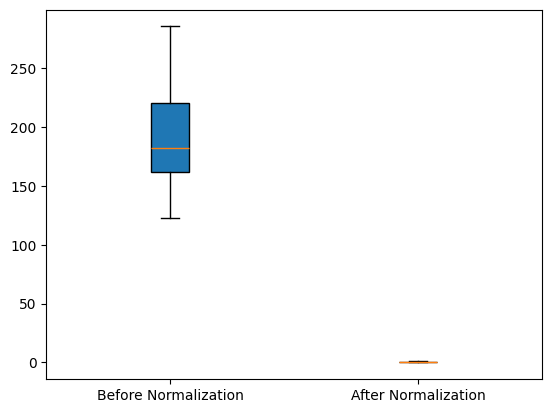

In [24]:
combined_data = [prices,prices_normalized]
plt.boxplot(combined_data,labels=['Before Normalization','After Normalization'],patch_artist=True)